## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
def load_data(p): return pd.read_csv(p)


### Load result to data frame


In [2]:
multi = load_data('multi/result.csv')


# Strategy Iteration Distribution — All Exits


Strategy Iteration Distribution (All Exits, n=279):
  iter=1: 155 (55.6%)
  iter=2:  37 (13.3%)
  iter=3:   6 (2.2%)
  iter=4:  81 (29.0%)

Syntax Iteration Distribution (All Exits):
  syntax_iter=0: 279 (100.0%)
    (Syntax agent never retries; retry loop is at strategy level)


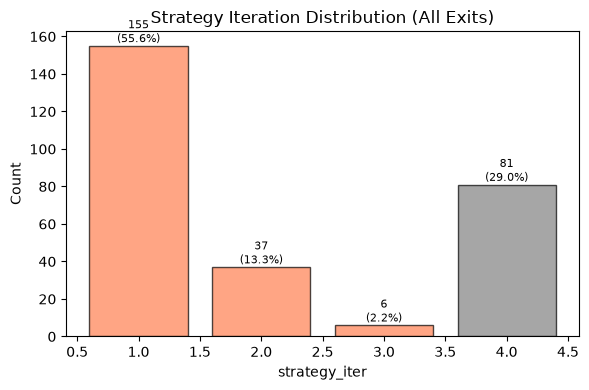

In [3]:
si_counts = multi['strategy_iter'].value_counts().sort_index()
print(f"Strategy Iteration Distribution (All Exits, n=279):")
for idx, cnt in si_counts.items():
    print(f"  iter={idx}: {cnt:3d} ({cnt/len(multi)*100:.1f}%)")
print()
print(f"Syntax Iteration Distribution (All Exits):")
sy_counts = multi['syntax_iter'].value_counts().sort_index()
for idx, cnt in sy_counts.items():
    print(f"  syntax_iter={idx}: {cnt:3d} ({cnt/len(multi)*100:.1f}%)")
print(f"    (Syntax agent never retries; retry loop is at strategy level)")

fig, ax = plt.subplots(figsize=(6, 4))
iters = list(si_counts.index)
counts = list(si_counts.values)
colors = ['gray' if i == 0 or i == 4 else 'coral' for i in iters]
bars = ax.bar(iters, counts, color=colors, edgecolor='black', alpha=0.7)
ax.set_title('Strategy Iteration Distribution (All Exits)')
ax.set_xlabel('strategy_iter')
ax.set_ylabel('Count')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{cnt}\n({cnt/len(multi)*100:.1f}%)', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('charts/iter/strategy_iter_distribution.png', dpi=100)
plt.show()


# Iterative Feedback Resolution Rate


ITERATIVE FEEDBACK RESOLUTION RATE
  Total runs:              279
  Entered strategy loop:   279  (100.0%)
    → Resolved (SUCCESS):  198  (71.0%)
    → Aborted:              81  (29.0%)

  First-pass success (iter=1): 155  (78.3% of resolved)

  Runs needing retry (iter>1): 124
    → Retry succeeds:          43  (34.7%)
    → Retry fails (abort):      81  (65.3%)


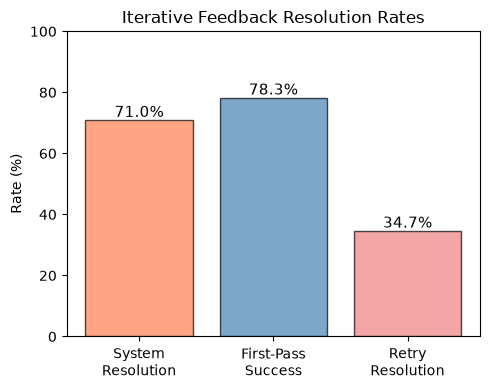

In [4]:
total = len(multi)
all_planned = multi[multi['strategy_iter'] > 0]  # entered strategy planning (iter 1-4)
succ_all = multi[multi['exit_status'] == 'SUCCESS']
abor_all = multi[multi['exit_status'] == 'ABORT_STRATEGY']
retry_needed = multi[multi['strategy_iter'] > 1]  # needed >1 iter
retry_succ = retry_needed[retry_needed['exit_status'] == 'SUCCESS']
retry_abor = retry_needed[retry_needed['exit_status'] == 'ABORT_STRATEGY']

entered = len(all_planned)
resolved_total = len(succ_all)
aborted_total = len(abor_all)
retry_n = len(retry_needed)
retry_resolved = len(retry_succ)
retry_failed = len(retry_abor)

print("=" * 55)
print("ITERATIVE FEEDBACK RESOLUTION RATE")
print("=" * 55)
print(f"  Total runs:              {total}")
print(f"  Entered strategy loop:   {entered}  ({entered/total*100:.1f}%)")
print(f"    → Resolved (SUCCESS):  {resolved_total}  ({resolved_total/entered*100:.1f}%)")
print(f"    → Aborted:              {aborted_total}  ({aborted_total/entered*100:.1f}%)")
print(f"")
print(f"  First-pass success (iter=1): {len(succ_all[succ_all['strategy_iter']==1])}  "
      f"({len(succ_all[succ_all['strategy_iter']==1])/resolved_total*100:.1f}% of resolved)")
print(f"")
print(f"  Runs needing retry (iter>1): {retry_n}")
print(f"    → Retry succeeds:          {retry_resolved}  ({retry_resolved/retry_n*100:.1f}%)")
print(f"    → Retry fails (abort):      {retry_failed}  ({retry_failed/retry_n*100:.1f}%)")
print(f"=" * 55)

metrics = ['System\nResolution', 'First-Pass\nSuccess', 'Retry\nResolution']
values = [resolved_total/entered*100, len(succ_all[succ_all['strategy_iter']==1])/resolved_total*100, retry_resolved/retry_n*100]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(metrics, values, color=['coral', 'steelblue', 'lightcoral'], edgecolor='black', alpha=0.7)
ax.set_title('Iterative Feedback Resolution Rates')
ax.set_ylabel('Rate (%)')
ax.set_ylim(0, 100)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('charts/iter/resolution_rate_summary.png', dpi=100)
plt.show()


# Iteration vs Output Quality — SUCCESS Only


Iteration Distribution (SUCCESS only, n=198):
  iter=1: 155 runs (78.3%)
  iter=2:  37 runs (18.7%)
  iter=3:   6 runs (3.0%)

CSR by strategy_iter (SUCCESS only):
  iter=1: CSR = 58.1% (90/155)
  iter=2: CSR = 56.8% (21/37)
  iter=3: CSR = 33.3% (2/6)


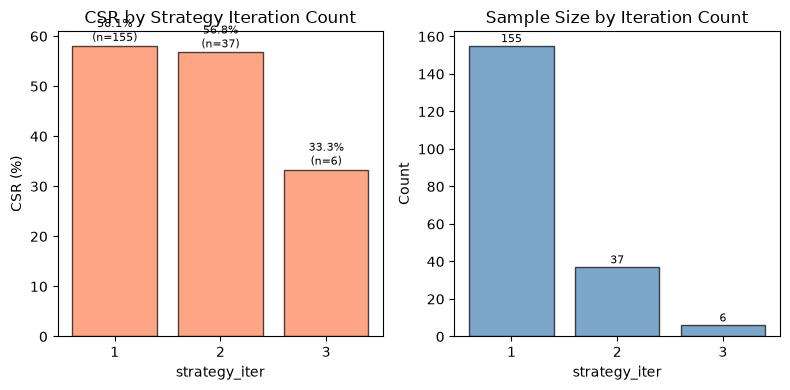

In [5]:
succ = multi[multi['exit_status'] == 'SUCCESS']
si_succ = succ['strategy_iter'].value_counts().sort_index()

print(f"Iteration Distribution (SUCCESS only, n={len(succ)}):")
for idx, cnt in si_succ.items():
    pct = cnt / len(succ) * 100
    print(f"  iter={idx}: {cnt:3d} runs ({pct:.1f}%)")

print(f"\nCSR by strategy_iter (SUCCESS only):")
iters = []
csr_vals = []
n_vals = []
for si in sorted(succ['strategy_iter'].unique()):
    s_sub = succ[succ['strategy_iter'] == si]
    csr = s_sub['csr_pass'].mean() * 100
    n = len(s_sub)
    csr_vals.append(csr)
    n_vals.append(n)
    iters.append(si)
    print(f"  iter={si}: CSR = {csr:.1f}% ({int(s_sub['csr_pass'].sum())}/{n})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].bar(range(len(iters)), csr_vals, color='coral', edgecolor='black', alpha=0.7, tick_label=[str(i) for i in iters])
axes[0].set_title('CSR by Strategy Iteration Count')
axes[0].set_xlabel('strategy_iter')
axes[0].set_ylabel('CSR (%)')
for i, (csr, n) in enumerate(zip(csr_vals, n_vals)):
    axes[0].text(i, csr + 1, f'{csr:.1f}%\n(n={n})', ha='center', fontsize=8)
axes[1].bar(range(len(iters)), n_vals, color='steelblue', edgecolor='black', alpha=0.7, tick_label=[str(i) for i in iters])
axes[1].set_title('Sample Size by Iteration Count')
axes[1].set_xlabel('strategy_iter')
axes[1].set_ylabel('Count')
for i, n in enumerate(n_vals):
    axes[1].text(i, n + 2, str(n), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('charts/iter/csr_by_iteration.png', dpi=100)
plt.show()


# Resolution Rate by Difficulty — SUCCESS Only


First-Pass Resolution by Difficulty (SUCCESS-Only):
  Easy   (n=54): iter=1: 44 (81.5%), iter=2: 10 (18.5%), iter=3:  0 (0.0%), mean=1.19
  Medium (n=104): iter=1: 82 (78.8%), iter=2: 17 (16.3%), iter=3:  5 (4.8%), mean=1.26
  Hard   (n=40): iter=1: 29 (72.5%), iter=2: 10 (25.0%), iter=3:  1 (2.5%), mean=1.30


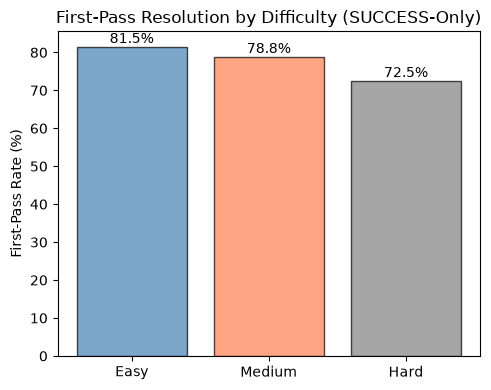

In [6]:
diffs = ['Easy', 'Medium', 'Hard']
print(f"First-Pass Resolution by Difficulty (SUCCESS-Only):")
diff_first = []
for diff in diffs:
    sub = succ[succ['difficulty'] == diff]
    n = len(sub)
    first = (sub['strategy_iter'] == 1).sum()
    second = (sub['strategy_iter'] == 2).sum()
    third = (sub['strategy_iter'] == 3).sum()
    mean_iter = sub['strategy_iter'].mean()
    diff_first.append(first / n * 100)
    print(f"  {diff:6s} (n={n:2d}): iter=1: {first:2d} ({first/n*100:.1f}%), iter=2: {second:2d} ({second/n*100:.1f}%), iter=3: {third:2d} ({third/n*100:.1f}%), mean={mean_iter:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(diffs, diff_first, color=['steelblue','coral','gray'], edgecolor='black', alpha=0.7)
ax.set_title('First-Pass Resolution by Difficulty (SUCCESS-Only)')
ax.set_ylabel('First-Pass Rate (%)')
for bar, v in zip(bars, diff_first):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('charts/iter/resolution_by_difficulty.png', dpi=100)
plt.show()


# Resolution Rate by Intent — SUCCESS Only


First-Pass Resolution by Intent (SUCCESS-Only):
  SPLIT_LOOP                     (n= 6): first-pass=33.3%, mean_iter=1.67
  REMOVE_CONTROL_FLAG            (n= 6): first-pass=50.0%, mean_iter=1.67
  CONSOLIDATE_CONDITIONAL        (n= 5): first-pass=60.0%, mean_iter=1.40
  INLINE_METHOD                  (n=12): first-pass=66.7%, mean_iter=1.42
  DECOMPOSE_CONDITIONAL          (n=44): first-pass=72.7%, mean_iter=1.30
  EXTRACT_CONSTANT               (n= 8): first-pass=75.0%, mean_iter=1.38
  RENAME_SYMBOL                  (n=36): first-pass=77.8%, mean_iter=1.28
  FLATTEN_CONDITIONAL            (n= 5): first-pass=80.0%, mean_iter=1.20
  REPLACE_LOOP_WITH_PIPELINE     (n=16): first-pass=81.2%, mean_iter=1.19
  INLINE_VARIABLE                (n=16): first-pass=87.5%, mean_iter=1.12
  EXTRACT_METHOD                 (n=42): first-pass=95.2%, mean_iter=1.05


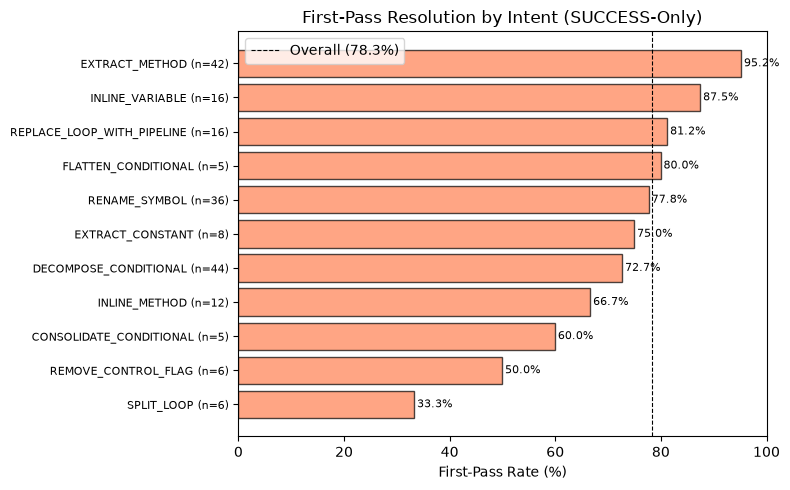

In [7]:
intent_res = []
for intent, sub in succ.groupby('intent'):
    n = len(sub)
    if n < 3:
        continue
    first = (sub['strategy_iter'] == 1).sum()
    mean_iter = sub['strategy_iter'].mean()
    intent_res.append({'intent': intent, 'n': n, 'first_pct': first/n*100, 'mean_iter': mean_iter})

df_res = pd.DataFrame(intent_res).sort_values('first_pct', ascending=True)
print(f"First-Pass Resolution by Intent (SUCCESS-Only):")
for _, r in df_res.iterrows():
    print(f"  {r['intent']:30s} (n={int(r['n']):2d}): first-pass={r['first_pct']:.1f}%, mean_iter={r['mean_iter']:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(df_res))
bars = ax.barh(y_pos, df_res['first_pct'], color='coral', alpha=0.7, edgecolor='black')
for bar, v in zip(bars, df_res['first_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r['intent']} (n={int(r['n'])})" for _, r in df_res.iterrows()], fontsize=8)
ax.set_xlabel('First-Pass Rate (%)')
ax.set_title('First-Pass Resolution by Intent (SUCCESS-Only)')
ax.axvline(78.3, color='black', linewidth=0.8, linestyle='--', label='Overall (78.3%)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/iter/resolution_by_intent.png', dpi=100)
plt.show()


#### Summary

**System Resolution Rate**: 71.0% (198/279) of planned runs succeed; 29.0% abort. Of runs needing retry (iter ≥ 2): 34.7% are rescued by the retry mechanism, 65.3% exhaust the budget and abort.

**First-Pass Success**: 78.3% of all resolved runs converge in the first strategy iteration — the planner's initial plan produces acceptable code without revision.

**By Difficulty**: First-pass rate decreases with difficulty — Easy 81.5%, Medium 78.8%, Hard 72.5%. Hard tasks are more likely to require strategy revisions.

**By Intent**: EXTRACT_METHOD (95.2%), INLINE_VARIABLE (87.5%), and REPLACE_LOOP_WITH_PIPELINE (81.2%) have the highest first-pass rates — these well-scoped transformations rarely need replanning. SPLIT_LOOP (33.3%), REMOVE_CONTROL_FLAG (50.0%), and CONSOLIDATE_CONDITIONAL (60.0%) have the lowest — structural loop/condition transformations challenge the strategy agent's initial plan.

**Quality vs Iterations**: CSR decreases with iteration count (58.1% → 56.8% → 33.3%). More iterations do not improve outcomes — they indicate the task was harder to plan for initially. The retry mechanism filters difficult cases rather than improving them.
